PROBLEM STATEMENT :
We are data scientist in a company and we need to built a classification model to predict employee attrition and identify key drivers influencing attrition.

WHAT WE NEED TO DO IS
*    Predict Attrition (Yes/No)
*    Explain WHY employees leave
*    Suggest business solutions

In [39]:
## Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [40]:
## Load the dataset

df = pd.read_csv("/content/HR-Employee-Attrition.csv")

In [41]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [42]:
# Check shape (rows, columns)
df.shape

(1470, 35)

In [43]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [44]:
# Statistical summary
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [45]:
# Drop useless columns
df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [46]:
## Outlier detection

def outlier_detection(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [47]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
for col in numerical_columns:
  df = outlier_detection(df, col)

In [48]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
11,29,No,Travel_Rarely,153,Research & Development,15,2,Life Sciences,4,Female,...,3,4,0,10,3,3,9,5,0,8
12,31,No,Travel_Rarely,670,Research & Development,26,1,Life Sciences,1,Male,...,3,4,1,5,1,2,5,2,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,31,No,Non-Travel,325,Research & Development,5,3,Medical,2,Male,...,3,2,0,10,2,3,9,4,1,7
1464,26,No,Travel_Rarely,1167,Sales,5,3,Other,4,Female,...,3,4,0,5,2,3,4,2,0,0
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


UNIVARIATE ANALYSIS

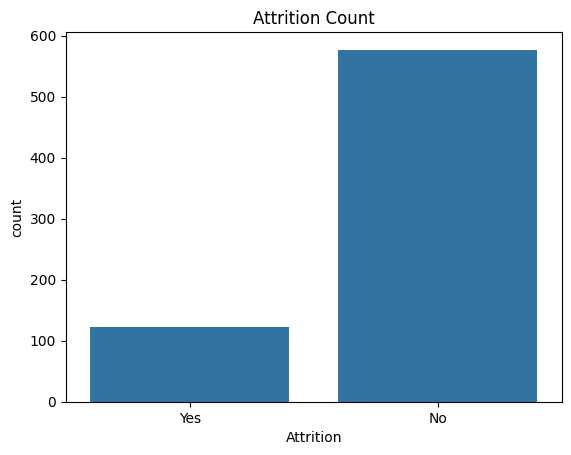

In [49]:
# Count of attrition (Yes/No)
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Count")
plt.show()

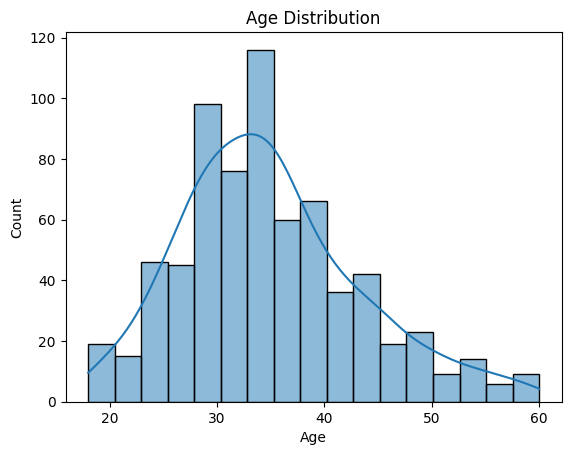

In [50]:
# Distribution of age
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

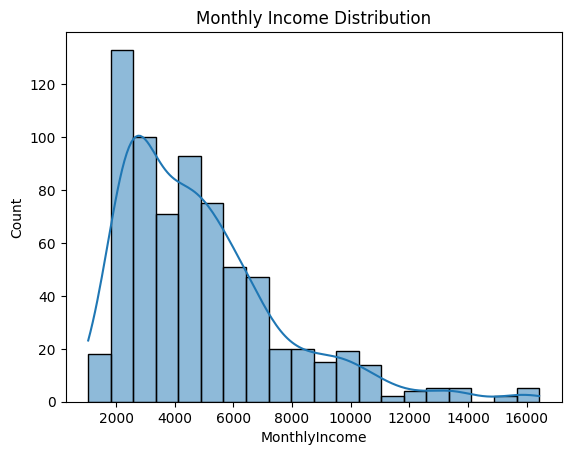

In [51]:
# Salary distribution
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

BIVARIATE ANALYSIS

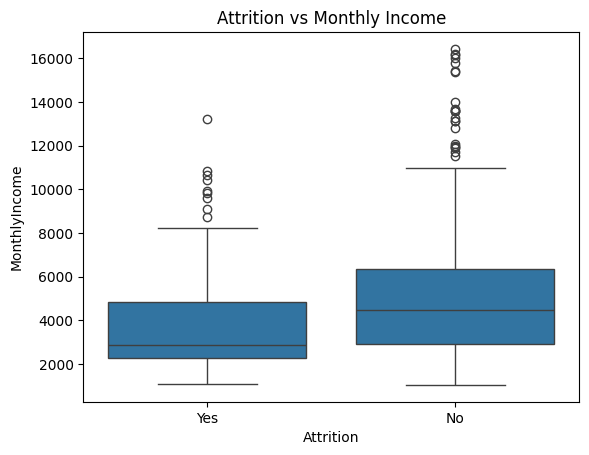

In [52]:
# Salary vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

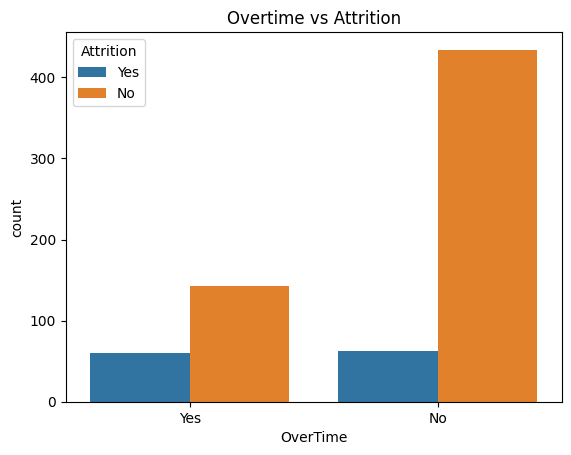

In [53]:
# Attrition vs Overtime
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()

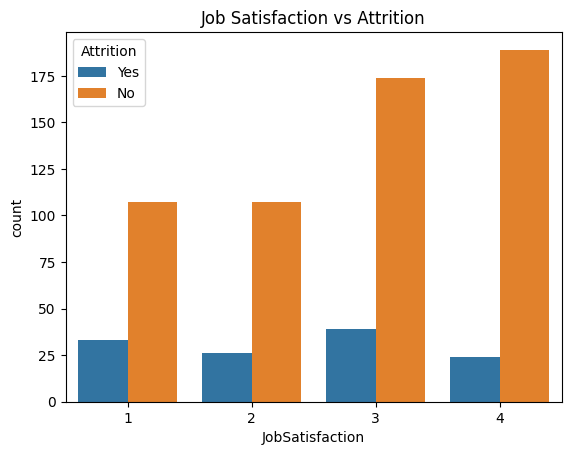

In [54]:
# Job Satisfaction vs Attrition
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

ENCODING

In [55]:
from sklearn.preprocessing import LabelEncoder

In [56]:
le_d = {}

In [57]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_columns:

    # Create a new LabelEncoder object
    le = LabelEncoder()

    # Convert text values into numeric values
    df[col] = le.fit_transform(df[col]) ## Example: Yes/No → 1/0 OR Male/Female → 1/0

    # Save encoder for that column
    le_d[col] = le  ## This helps when new data comes

In [58]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
5,32,0,1,1005,1,2,2,1,4,1,...,3,3,0,8,2,2,7,7,3,6
11,29,0,2,153,1,15,2,1,4,0,...,3,4,0,10,3,3,9,5,0,8
12,31,0,2,670,1,26,1,1,1,1,...,3,4,1,5,1,2,5,2,4,3


In [59]:
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,int64
DailyRate,int64
Department,int64
DistanceFromHome,int64
Education,int64
EducationField,int64
EnvironmentSatisfaction,int64
Gender,int64


In [60]:
df = df.replace({True: 1, False: 0})

In [61]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
5,32,0,1,1005,1,2,2,1,4,1,...,3,3,0,8,2,2,7,7,3,6
11,29,0,2,153,1,15,2,1,4,0,...,3,4,0,10,3,3,9,5,0,8
12,31,0,2,670,1,26,1,1,1,1,...,3,4,1,5,1,2,5,2,4,3


TRAIN-TEST SPLIT

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
# Define features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [64]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  MODEL BUILDING

In [65]:
## Importing multiple models

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [66]:
nb = GaussianNB()
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

In [67]:
## Training the model

nb.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [68]:
## Model evaluation

nb_pred = nb.predict(X_test)
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

In [70]:
cm = metrics.confusion_matrix(y_test, rf_pred)

In [71]:
# Print matrix
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[115   2]
 [ 19   4]]


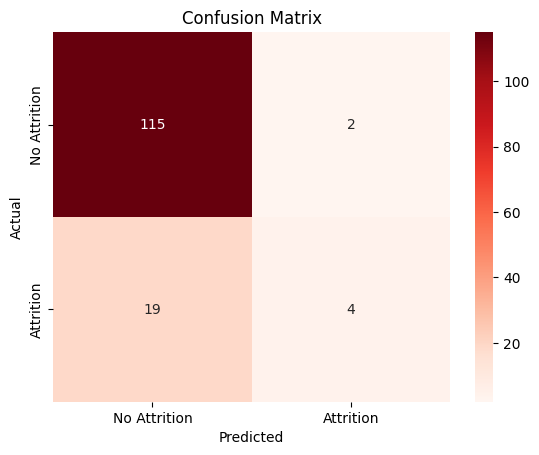

In [77]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [78]:
nb_acc = metrics.accuracy_score(y_test, nb_pred)
rf_acc = metrics.accuracy_score(y_test, rf_pred)
dt_acc = metrics.accuracy_score(y_test, dt_pred)

In [79]:
print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Random Forest: ", rf_acc)
print("Accuracy for Decision Tree: ", dt_acc)

Accuracy for Naive Bayes:  0.7285714285714285
Accuracy for Random Forest:  0.85
Accuracy for Decision Tree:  0.75


In [80]:
best_model = rf

In [81]:
# Create new employee data (example)
new_data = pd.DataFrame({
    'Age': [30],
    'MonthlyIncome': [4000],
    'TotalWorkingYears': [5],
    'YearsAtCompany': [3],
    'DistanceFromHome': [10],
    'JobSatisfaction': [2],
    'WorkLifeBalance': [2],
    'OverTime': ['Yes'],
    'BusinessTravel': ['Travel_Rarely'],
    'Department': ['Sales'],
    'JobRole': ['Sales Executive'],
    'MaritalStatus': ['Single'],
    'Gender': ['Male']
})

In [82]:
# Apply saved encoders
for col in le_d:
    if col in new_data.columns:
        new_data[col] = le_d[col].transform(new_data[col])

In [84]:
# Create a new DataFrame with the same columns as X, filled with zeros
# This ensures that all necessary columns are present for prediction
aligned_new_data = pd.DataFrame(0, index=new_data.index, columns=X.columns)

# Copy the values from the existing new_data into the aligned_new_data
# for the columns that are present in both.
for col in new_data.columns:
    if col in aligned_new_data.columns:
        aligned_new_data[col] = new_data[col]

# Replace new_data with the aligned version
new_data = aligned_new_data

In [85]:
# Prediction
prediction = rf.predict(new_data)

In [86]:
new_data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,30,2,0,2,10,0,0,0,1,0,...,0,0,0,5,0,2,3,0,0,0


In [89]:
if prediction[0] == 1:
    print(" Employee is likely to leave (Attrition = Yes)")
else:
    print(" Employee is likely to stay (Attrition = No)")

 Employee is likely to stay (Attrition = No)


In [90]:
prediction

array([0])

In [91]:
# Probability of leaving
prob = rf.predict_proba(new_data)

print("Probability of staying:", prob[0][0])
print("Probability of leaving:", prob[0][1])

Probability of staying: 0.5
Probability of leaving: 0.5
